In [24]:
import subprocess
result = subprocess.run([
    "pip", "install",
    "--pre",
    "torch", "torchvision", "torchaudio",
    "--index-url", "https://download.pytorch.org/whl/nightly/cu128",
    "--upgrade"
], capture_output=True, text=True)
print(result.stdout[-3000:])
print(result.stderr[-2000:])


_system == "Linux"->torch) (12.8.90)




In [25]:
import os
import random
import hashlib

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ──────────────────────────────────────────────────────
# Global configuration — edit here only
# ──────────────────────────────────────────────────────
NUM_CHANNELS      = 6        # 6-channel expanded colour space
IMAGE_SIZE        = (NUM_CHANNELS, 64, 64)
BATCH_SIZE        = 32
EPOCHS            = 200
LEARNING_RATE     = 1e-4
LATENT_DIM        = 1024
NGF               = 64       # Generator base feature-map count
NDF               = 64       # Discriminator base feature-map count (matched to NGF — was 32)
GEN_DROPOUT       = 0.2      # Reduced from 0.5; Dropout2d at 0.5 kills too many feature maps
DISC_DROPOUT      = 0.15     # Slight regularisation on discriminator
NOISE_INJECTION_G = 0.15     # Feature-map noise in generator (reduced from 0.3)
NOISE_INJECTION_D = 0.10     # Input noise to discriminator (reduced from 0.3)
LABEL_FLIP_PROB   = 0.05     # Only real labels are flipped (not both simultaneously)
GRAD_CLIP         = 5.0
LAMBDA_UNIFORM    = 0.5      # Weight for the differentiable uniformity loss
MODEL_PATH_G      = "expanded_generator_dcgan.pth"
MODEL_PATH_D      = "expanded_discriminator_dcgan.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [26]:
class CSPRNGNoiseDataset(Dataset):
    """
    Generates images filled with cryptographic randomness (os.urandom).
    Each call to __getitem__ produces a fresh independently-sampled image,
    so the model sees effectively infinite unique samples.
    Output is normalised to [-1, 1] to match the Tanh generator output range.
    """
    def __init__(self, num_images: int = 5000, image_size: tuple = IMAGE_SIZE):
        super().__init__()
        self.num_images = num_images
        self.channels, self.height, self.width = image_size
        self.num_pixels = self.channels * self.height * self.width

    def __len__(self):
        return self.num_images

    def __getitem__(self, idx):
        raw_bytes = os.urandom(self.num_pixels)
        img_array = np.frombuffer(raw_bytes, dtype=np.uint8).reshape(
            self.channels, self.height, self.width
        ).copy()  # .copy() because frombuffer returns a read-only array
        # Normalise to [-1, 1] — consistent with Tanh output in the generator
        img_tensor = torch.tensor(img_array, dtype=torch.float32) / 127.5 - 1.0
        return img_tensor


def get_csprng_dataloader(batch_size: int = BATCH_SIZE) -> DataLoader:
    dataset = CSPRNGNoiseDataset()
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=(DEVICE.type == "cuda"),
    )


train_loader = get_csprng_dataloader()
print(f"DataLoader ready — {len(train_loader.dataset)} virtual samples, batch size {BATCH_SIZE}")


DataLoader ready — 5000 virtual samples, batch size 32


In [27]:
class NoiseInjection(nn.Module):
    """
    Adds per-element Gaussian noise to intermediate feature maps during training.
    Encourages stochastic diversity in generated outputs.
    Disabled at eval time so inference is deterministic given a fixed z.
    """
    def __init__(self, scale: float = 0.15):
        super().__init__()
        self.scale = scale

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.training:
            return x + torch.randn_like(x) * self.scale
        return x


class DiscriminatorInputNoise(nn.Module):
    """
    Adds small Gaussian noise to discriminator inputs.
    Prevents D from memorising exact input values; acts as instance noise.
    Scale is intentionally small (0.10) to avoid masking real structure.
    """
    def __init__(self, scale: float = 0.10):
        super().__init__()
        self.scale = scale

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.training:
            return x + torch.randn_like(x) * self.scale
        return x


In [28]:
class ResizeConvBlock(nn.Module):
    """
    Replaces ConvTranspose2d(stride=2) with Upsample + Conv2d.
    Eliminates checkerboard artifacts caused by uneven gradient weighting
    in stride-2 transposed convolutions. Standard fix from Odena et al. 2016.
    """
    def __init__(self, in_channels, out_channels, scale_factor=2, noise_scale=0.15, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Upsample(scale_factor=scale_factor, mode='nearest'),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(True),
            NoiseInjection(noise_scale),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.block(x)


class Generator(nn.Module):
    """
    Resize-convolution generator. Identical capacity to the previous version
    but without ConvTranspose2d, so no checkerboard artifacts.

    Upsample(nearest) + Conv2d has the same receptive field growth as
    ConvTranspose2d(stride=2) without the periodic gradient weighting problem.
    """
    def __init__(
        self,
        latent_dim:   int   = LATENT_DIM,
        ngf:          int   = NGF,
        num_channels: int   = NUM_CHANNELS,
        dropout:      float = GEN_DROPOUT,
        noise_scale:  float = NOISE_INJECTION_G,
    ):
        super().__init__()

        # Project latent vector to 4x4 spatial feature map
        # Still use ConvTranspose2d here (1x1 → 4x4, stride=4): no checkerboard
        # because there's no stride-2 overlap ambiguity at this scale
        self.project = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            NoiseInjection(noise_scale),
            nn.Dropout(dropout),
        )

        # 4x4 → 8x8
        self.up1 = ResizeConvBlock(ngf * 8, ngf * 4, noise_scale=noise_scale, dropout=dropout)
        # 8x8 → 16x16
        self.up2 = ResizeConvBlock(ngf * 4, ngf * 2, noise_scale=noise_scale, dropout=dropout)
        # 16x16 → 32x32
        self.up3 = ResizeConvBlock(ngf * 2, ngf,     noise_scale=noise_scale, dropout=dropout)
        # 32x32 → 64x64 — final layer: no BN, no noise, no dropout
        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(ngf, num_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        x = self.project(z)
        x = self.up1(x)
        x = self.up2(x)
        x = self.up3(x)
        return self.final(x)


In [29]:
class Discriminator(nn.Module):
    """
    DCGAN-style discriminator with spectral normalisation.
    Accepts NUM_CHANNELS x 64 x 64 images.

    Key changes vs. original:
    - NDF raised from 32 to 64 (matches NGF). Original D was too weak relative to G.
    - Added a 4th strided conv so depth matches the generator.
    - Spectral normalisation on every conv layer replaces instance noise as the
      stability mechanism. SN constrains the Lipschitz constant without corrupting inputs.
    - Sigmoid removed from final layer; BCEWithLogitsLoss handles that numerically.
    """
    def __init__(
        self,
        ndf:          int   = NDF,
        num_channels: int   = NUM_CHANNELS,
        dropout:      float = DISC_DROPOUT,
    ):
        super().__init__()
        self.input_noise = DiscriminatorInputNoise(scale=NOISE_INJECTION_D)

        sn = nn.utils.spectral_norm

        self.main = nn.Sequential(
            # 64x64 → 32x32
            sn(nn.Conv2d(num_channels, ndf, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(dropout),

            # 32x32 → 16x16
            sn(nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(dropout),

            # 16x16 → 8x8
            sn(nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(dropout),

            # 8x8 → 4x4
            sn(nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(dropout),

            # 4x4 → 1x1 — raw logit, no Sigmoid
            sn(nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False)),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.input_noise(x)
        return self.main(x).view(-1)


In [30]:
def weights_init(m: nn.Module) -> None:
    """
    DCGAN-standard weight initialisation.
    Matches on exact PyTorch layer types instead of classname string matching,
    which avoids false matches on custom module names like ResizeConvBlock.
    """
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        # spectral_norm stores the raw weight as weight_orig
        weight_attr = "weight_orig" if hasattr(m, "weight_orig") else "weight"
        nn.init.normal_(getattr(m, weight_attr).data, 0.0, 0.02)
    elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)


def init_generator_final_layer(model: nn.Module) -> None:
    """
    Wider uniform init on the generator's final Conv2d output layer
    to encourage value spread from the first forward pass.
    Targets the Conv2d immediately before Tanh (out_channels == NUM_CHANNELS).
    """
    for m in model.modules():
        if isinstance(m, nn.Conv2d) and m.out_channels == NUM_CHANNELS:
            nn.init.uniform_(m.weight.data, -0.5, 0.5)


netG = Generator().to(DEVICE)
netD = Discriminator().to(DEVICE)

netG.apply(weights_init)
netD.apply(weights_init)
init_generator_final_layer(netG)

param_G = sum(p.numel() for p in netG.parameters() if p.requires_grad)
param_D = sum(p.numel() for p in netD.parameters() if p.requires_grad)
print(f"Generator parameters:     {param_G:,}")
print(f"Discriminator parameters: {param_D:,}")
print(f"Generator:\n{netG}")
print(f"\nDiscriminator:\n{netD}")


Generator parameters:     9,942,272
Discriminator parameters: 2,768,640
Generator:
Generator(
  (project): Sequential(
    (0): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): NoiseInjection()
    (4): Dropout(p=0.2, inplace=False)
  )
  (up1): ResizeConvBlock(
    (block): Sequential(
      (0): Upsample(scale_factor=2.0, mode='nearest')
      (1): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (3): ReLU(inplace=True)
      (4): NoiseInjection()
      (5): Dropout(p=0.2, inplace=False)
    )
  )
  (up2): ResizeConvBlock(
    (block): Sequential(
      (0): Upsample(scale_factor=2.0, mode='nearest')
      (1): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=Fal

In [31]:
def soft_uniformity_loss(x: torch.Tensor, n_samples: int = 2048) -> torch.Tensor:
    """
    Differentiable uniformity loss. Samples n_samples values from the flattened
    generator output, sorts them, then computes MSE against linearly-spaced targets
    (the order statistics of a uniform distribution). This is a 1D Wasserstein-1
    proxy and has well-defined gradients through the sorted outputs.

    Replaces the original torch.histc approach, which had zero gradient with
    respect to the generator output and therefore contributed nothing to training.
    """
    flat = x.reshape(-1)
    n = min(n_samples, flat.shape[0])
    idx = torch.randperm(flat.shape[0], device=x.device)[:n]
    sampled = flat[idx]
    sorted_gen, _ = torch.sort(sampled)
    sorted_target = torch.linspace(
        sampled.min().item(), sampled.max().item(), n, device=x.device
    )
    return F.mse_loss(sorted_gen, sorted_target)


# BCEWithLogitsLoss instead of BCE(Sigmoid(x)) — numerically stable
criterion = nn.BCEWithLogitsLoss()

optimizerG = optim.Adam(netG.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))

print("Loss: BCEWithLogitsLoss (logit-space, no Sigmoid needed on D output)")
print(f"Uniformity loss weight (lambda): {LAMBDA_UNIFORM}")


Loss: BCEWithLogitsLoss (logit-space, no Sigmoid needed on D output)
Uniformity loss weight (lambda): 0.5


Epoch 1/200: 100%|██████████| 157/157 [00:05<00:00, 30.99it/s]


Epoch [1/200] D_loss: 1.1451  G_loss: 2.4442  Uni_loss: 0.2088


Epoch 2/200: 100%|██████████| 157/157 [00:04<00:00, 34.22it/s]


Epoch [2/200] D_loss: 0.7596  G_loss: 3.7997  Uni_loss: 0.1961


Epoch 3/200: 100%|██████████| 157/157 [00:04<00:00, 33.59it/s]


...

Epoch [198/200] D_loss: 0.4577  G_loss: 9.8591  Uni_loss: 0.1644


Epoch 199/200: 100%|██████████| 157/157 [00:04<00:00, 34.75it/s]


Epoch [199/200] D_loss: 0.4168  G_loss: 9.8797  Uni_loss: 0.1674


Epoch 200/200: 100%|██████████| 157/157 [00:04<00:00, 34.88it/s]


Epoch [200/200] D_loss: 0.4192  G_loss: 9.9018  Uni_loss: 0.1719

Saved generator  → expanded_generator_dcgan.pth
Saved discriminator → expanded_discriminator_dcgan.pth


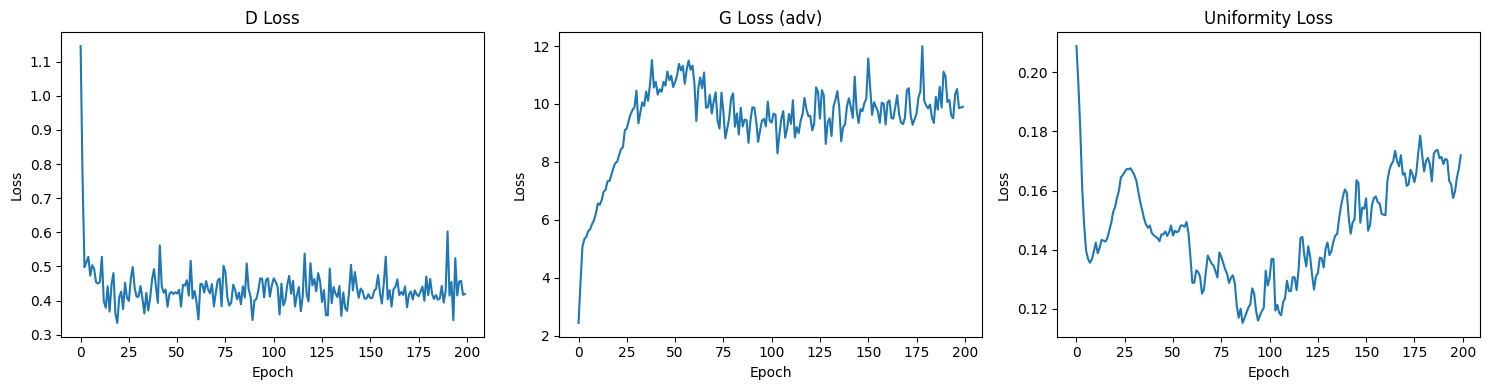

In [32]:
def train_dcgan(epochs: int = EPOCHS) -> None:
    """
    Improvements over original:
    1. BCEWithLogitsLoss on raw D logits — numerically stable.
    2. One-sided label smoothing: real=0.9, fake=0.0. Only real labels flip
       (probability LABEL_FLIP_PROB). Original swapped both simultaneously, which
       is incorrect — it told D fake=real AND real=fake in the same step.
    3. Differentiable soft uniformity loss on G (Wasserstein-1 proxy, has gradients).
    4. G trains twice per D step when D loss < 0.2 to prevent D from running away.
    5. Gradient clipping on both networks.
    """
    netG.train()
    netD.train()

    loss_history = {"D": [], "G": [], "uni": []}

    for epoch in range(epochs):
        epoch_d, epoch_g, epoch_uni = [], [], []

        for i, real_data in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")):
            b_size = real_data.size(0)
            real_data = real_data.to(DEVICE)

            # ── Train Discriminator ──────────────────────────────────────────
            netD.zero_grad()

            # One-sided label smoothing: real=0.9, fake=0.0
            label_real = torch.full((b_size,), 0.9, dtype=torch.float, device=DEVICE)
            label_fake = torch.zeros(b_size, dtype=torch.float, device=DEVICE)

            # Flip only real labels, not both simultaneously
            if random.random() < LABEL_FLIP_PROB:
                label_real = torch.zeros(b_size, dtype=torch.float, device=DEVICE)

            out_real = netD(real_data)
            errD_real = criterion(out_real, label_real)

            z = torch.randn(b_size, LATENT_DIM, 1, 1, device=DEVICE)
            fake_data = netG(z)
            out_fake = netD(fake_data.detach())
            errD_fake = criterion(out_fake, label_fake)

            errD = errD_real + errD_fake
            errD.backward()
            nn.utils.clip_grad_norm_(netD.parameters(), GRAD_CLIP)
            optimizerD.step()

            # ── Train Generator ──────────────────────────────────────────────
            # Train G twice when D is dominating to restore balance
            g_steps = 2 if errD.item() < 0.2 else 1

            for _ in range(g_steps):
                netG.zero_grad()
                label_for_g = torch.ones(b_size, dtype=torch.float, device=DEVICE)
                z2 = torch.randn(b_size, LATENT_DIM, 1, 1, device=DEVICE)
                fake_data2 = netG(z2)
                out_gen = netD(fake_data2)
                errG_adv = criterion(out_gen, label_for_g)

                # Differentiable uniformity loss — pushes output toward flat distribution
                uni_loss = soft_uniformity_loss(fake_data2)

                errG = errG_adv + LAMBDA_UNIFORM * uni_loss
                errG.backward()
                nn.utils.clip_grad_norm_(netG.parameters(), GRAD_CLIP)
                optimizerG.step()

            epoch_d.append(errD.item())
            epoch_g.append(errG_adv.item())
            epoch_uni.append(uni_loss.item())

        mean_d   = np.mean(epoch_d)
        mean_g   = np.mean(epoch_g)
        mean_uni = np.mean(epoch_uni)
        loss_history["D"].append(mean_d)
        loss_history["G"].append(mean_g)
        loss_history["uni"].append(mean_uni)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"D_loss: {mean_d:.4f}  G_loss: {mean_g:.4f}  Uni_loss: {mean_uni:.4f}"
        )

    torch.save(netG.state_dict(), MODEL_PATH_G)
    torch.save(netD.state_dict(), MODEL_PATH_D)
    print(f"\nSaved generator  → {MODEL_PATH_G}")
    print(f"Saved discriminator → {MODEL_PATH_D}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (key, label) in zip(axes, [("D","D Loss"), ("G","G Loss (adv)"), ("uni","Uniformity Loss")]):
        ax.plot(loss_history[key])
        ax.set_title(label)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=100)
    plt.show()


# Uncomment to train:
train_dcgan()


In [33]:
def load_generator(model_path: str = MODEL_PATH_G) -> Generator:
    gen = Generator().to(DEVICE)
    gen.load_state_dict(torch.load(model_path, map_location=DEVICE))
    gen.eval()
    return gen


def generate_images(gen: Generator, n_images: int = 100) -> list:
    """
    Generates n_images tensors from the loaded generator.
    Each image shape: (NUM_CHANNELS, 64, 64), values in [-1, 1].
    Processed in batches of 64 to avoid OOM on large n_images.
    """
    gen.eval()
    images = []
    with torch.no_grad():
        for start in range(0, n_images, 64):
            count = min(64, n_images - start)
            z = torch.randn(count, LATENT_DIM, 1, 1, device=DEVICE)
            fake = gen(z)
            images.extend(fake.cpu().unbind(0))
    return images


loaded_gen = load_generator(MODEL_PATH_G)
print(f"Loaded generator from {MODEL_PATH_G}")
generated_images = generate_images(loaded_gen, n_images=10000)
print(f"Generated {len(generated_images)} images")


Loaded generator from expanded_generator_dcgan.pth
Generated 10000 images


In [34]:
def cdf_quantise(images: list, target_bytes: int = 1_000_000, shuffle: bool = True) -> bytes:
    """
    CDF mapping to bytes, with optional byte-stream shuffling.

    Shuffling is critical: the generator's spatial correlations make adjacent
    bytes (which correspond to adjacent pixels) correlated. Shuffling destroys
    the spatial ordering, so the resulting byte stream has no inter-byte
    correlation structure from the convolutional architecture.

    shuffle=True is correct for randomness evaluation and use.
    shuffle=False is useful for debugging to see raw spatial correlations.
    """
    all_values = np.concatenate([
        img.detach().numpy().astype(np.float32).ravel()
        for img in images
    ])

    print(f"Total float values: {len(all_values):,}")
    print(f"Raw range: [{all_values.min():.4f}, {all_values.max():.4f}]")
    print(f"Mean: {all_values.mean():.4f}  Std: {all_values.std():.4f}")

    ranks = np.argsort(np.argsort(all_values))
    n = len(ranks)
    byte_values = (ranks / (n - 1) * 255).astype(np.uint8)

    if shuffle:
        # Use a cryptographic seed so the shuffle is reproducible but not predictable
        rng = np.random.default_rng(seed=int.from_bytes(os.urandom(8), 'little'))
        rng.shuffle(byte_values)
        print("Byte stream shuffled (spatial ordering destroyed)")

    result = byte_values.tobytes()
    trimmed = result[:target_bytes]
    print(f"Available: {len(result):,} bytes  |  Returning: {len(trimmed):,} bytes")
    return trimmed


gan_bytes_raw = cdf_quantise(generated_images, target_bytes=1_000_000)
print(f"\nByte stream ready: {len(gan_bytes_raw):,} bytes")


Total float values: 245,760,000
Raw range: [-1.0000, 1.0000]
Mean: 0.0400  Std: 0.8377
Byte stream shuffled (spatial ordering destroyed)
Available: 245,760,000 bytes  |  Returning: 1,000,000 bytes

Byte stream ready: 1,000,000 bytes


In [35]:
from scipy.stats import ks_1samp, chisquare, uniform as sp_uniform
from numpy.fft import fft


def shannon_entropy(data: bytes) -> float:
    """Shannon entropy in bits per byte. Max = 8.0 for perfectly uniform bytes."""
    counts = np.bincount(np.frombuffer(data, dtype=np.uint8), minlength=256)
    probs = counts / float(len(data))
    probs = probs[probs > 0]
    return float(-np.sum(probs * np.log2(probs)))


def ks_test_uniform(data: bytes) -> tuple:
    """
    KS test against Uniform[0,1]. p > 0.05 means cannot reject uniformity.
    Capped at 50,000 samples — KS becomes over-sensitive at very large N.
    """
    arr = np.frombuffer(data, dtype=np.uint8).astype(np.float64) / 255.0
    if len(arr) > 50_000:
        arr = np.random.choice(arr, size=50_000, replace=False)
    stat, p = ks_1samp(arr, sp_uniform.cdf)
    return float(stat), float(p)


def chi_square_test(data: bytes) -> tuple:
    """
    Chi-square goodness-of-fit against uniform over 256 bins.
    Needs >= 25,600 bytes for meaningful expected counts (>=100 per bin).
    """
    observed = np.bincount(np.frombuffer(data, dtype=np.uint8), minlength=256).astype(float)
    expected = np.full(256, len(data) / 256.0)
    stat, p = chisquare(observed, f_exp=expected)
    return float(stat), float(p)


def autocorrelation(data: bytes, lag: int = 1) -> float:
    """Normalised autocorrelation at a given lag. Values near 0 = little sequential dependence."""
    arr = np.frombuffer(data, dtype=np.uint8).astype(np.float64)
    n = len(arr)
    mean = arr.mean()
    c0 = np.sum((arr - mean) ** 2) / n
    if c0 == 0:
        return 0.0
    c_lag = np.sum((arr[:n - lag] - mean) * (arr[lag:] - mean)) / n
    return float(c_lag / c0)


def bitwise_balance(data: bytes) -> tuple:
    """Count 0-bits and 1-bits. Ideal: ones fraction = 0.5."""
    bits = np.unpackbits(np.frombuffer(data, dtype=np.uint8))
    ones = int(np.sum(bits))
    zeros = len(bits) - ones
    return zeros, ones, ones / len(bits)


def most_frequent_bin(data: bytes) -> tuple:
    """Returns (byte_value, count) for the most common byte."""
    counts = np.bincount(np.frombuffer(data, dtype=np.uint8), minlength=256)
    idx = int(np.argmax(counts))
    return idx, int(counts[idx])


print("Evaluation functions loaded.")


Evaluation functions loaded.


In [44]:
EVAL_BYTES = 100_000  # Large enough for meaningful chi-square (391 expected per bin)

csprng_sample = os.urandom(EVAL_BYTES)
gan_start     = random.randint(0, max(0, len(gan_bytes_raw) - EVAL_BYTES))
gan_sample    = gan_bytes_raw[gan_start : gan_start + EVAL_BYTES]

assert len(gan_sample) == EVAL_BYTES, f"Need {EVAL_BYTES} bytes, have {len(gan_bytes_raw)}"

gan_entropy,    csprng_entropy    = shannon_entropy(gan_sample),  shannon_entropy(csprng_sample)
gan_ks_stat,    gan_ks_p          = ks_test_uniform(gan_sample)
csprng_ks_stat, csprng_ks_p       = ks_test_uniform(csprng_sample)
gan_chi2_stat,  gan_chi2_p        = chi_square_test(gan_sample)
csprng_chi2_stat, csprng_chi2_p   = chi_square_test(csprng_sample)
gan_autocorr,   csprng_autocorr   = autocorrelation(gan_sample), autocorrelation(csprng_sample)
gan_zeros,      gan_ones,  gan_ratio    = bitwise_balance(gan_sample)
csprng_zeros, csprng_ones, csprng_ratio = bitwise_balance(csprng_sample)
gan_mode_val,   gan_mode_freq     = most_frequent_bin(gan_sample)
csprng_mode_val, csprng_mode_freq = most_frequent_bin(csprng_sample)
expected_per_bin = EVAL_BYTES / 256

print(f"\n{'─'*80}")
print(f"{'Metric':<35} {'GAN':<22} {'CSPRNG (urandom)':<22}")
print(f"{'─'*80}")
print(f"{'Shannon Entropy (bits/byte)':<35} {gan_entropy:<22.4f} {csprng_entropy:<22.4f}")
print(f"{'  → ideal: 8.0'}")
print(f"{'─'*80}")
print(f"{'KS Statistic':<35} {gan_ks_stat:<22.4f} {csprng_ks_stat:<22.4f}")
print(f"{'KS p-value':<35} {gan_ks_p:<22.4f} {csprng_ks_p:<22.4f}")
print(f"{'  → p > 0.05 = cannot reject uniformity'}")
print(f"{'─'*80}")
print(f"{'Chi-Square Statistic':<35} {gan_chi2_stat:<22.2f} {csprng_chi2_stat:<22.2f}")
print(f"{'Chi-Square p-value':<35} {gan_chi2_p:<22.4f} {csprng_chi2_p:<22.4f}")
print(f"{'  → expected per bin: '}{expected_per_bin:.1f}")
print(f"{'─'*80}")
print(f"{'Autocorrelation (lag=1)':<35} {gan_autocorr:<22.4f} {csprng_autocorr:<22.4f}")
print(f"{'  → ideal: ~0.0'}")
print(f"{'─'*80}")
print(f"{'Bit Balance (ones fraction)':<35} {gan_ratio:<22.4f} {csprng_ratio:<22.4f}")
print(f"{'  → ideal: 0.5'}")
print(f"{'─'*80}")
print(f"{'Mode byte value':<35} {gan_mode_val:<22} {csprng_mode_val:<22}")
print(f"{'Mode frequency':<35} {gan_mode_freq:<22} {csprng_mode_freq:<22}")
print(f"{'─'*80}\n")



────────────────────────────────────────────────────────────────────────────────
Metric                              GAN                    CSPRNG (urandom)      
────────────────────────────────────────────────────────────────────────────────
Shannon Entropy (bits/byte)         7.9926                 7.9982                
  → ideal: 8.0
────────────────────────────────────────────────────────────────────────────────
KS Statistic                        0.0093                 0.0049                
KS p-value                          0.0003                 0.1850                
  → p > 0.05 = cannot reject uniformity
────────────────────────────────────────────────────────────────────────────────
Chi-Square Statistic                633.08                 245.22                
Chi-Square p-value                  0.0000                 0.6587                
  → expected per bin: 390.6
────────────────────────────────────────────────────────────────────────────────
Autocorrelation (la

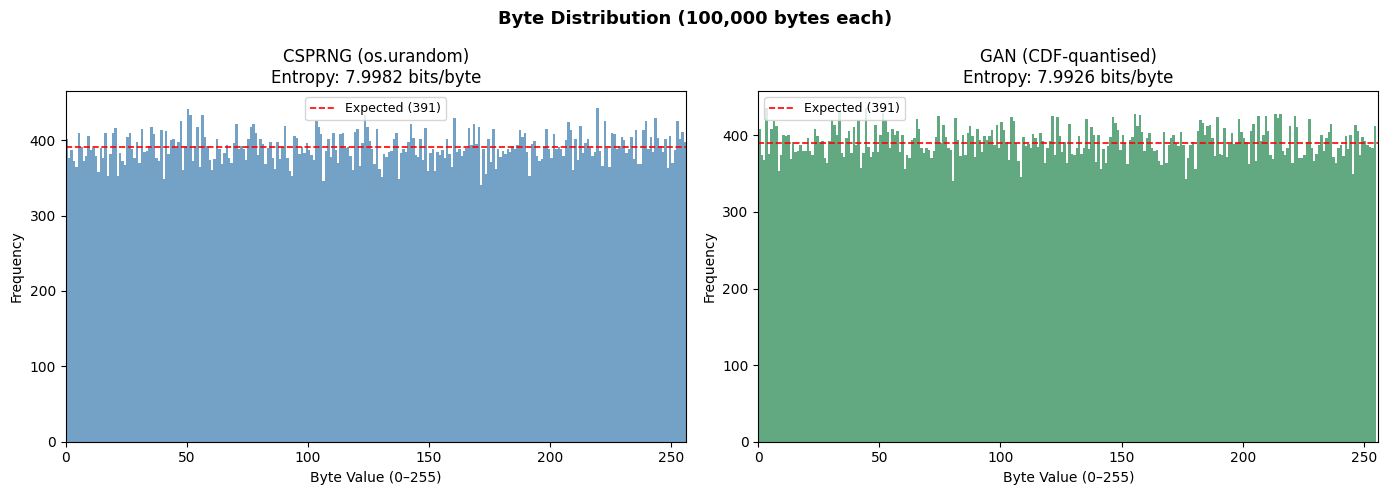

In [45]:
def plot_histogram_compare(
    data1: bytes,
    data2: bytes,
    label1: str = "CSPRNG (os.urandom)",
    label2: str = "GAN (CDF-quantised)",
) -> None:
    arr1, arr2 = np.frombuffer(data1, dtype=np.uint8), np.frombuffer(data2, dtype=np.uint8)
    ent1, ent2 = shannon_entropy(data1), shannon_entropy(data2)
    expected   = EVAL_BYTES / 256.0

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, arr, label, ent, color in zip(
        axes,
        [arr1, arr2],
        [label1, label2],
        [ent1, ent2],
        ["steelblue", "seagreen"],
    ):
        ax.hist(arr, bins=256, range=(0, 256), color=color, alpha=0.75)
        ax.axhline(expected, color="red", linestyle="--", linewidth=1.2,
                   label=f"Expected ({expected:.0f})")
        ax.set_title(f"{label}\nEntropy: {ent:.4f} bits/byte", fontsize=12)
        ax.set_xlabel("Byte Value (0–255)")
        ax.set_ylabel("Frequency")
        ax.set_xlim(0, 256)
        ax.legend(fontsize=9)

    plt.suptitle(f"Byte Distribution ({EVAL_BYTES:,} bytes each)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("histogram_comparison.png", dpi=120)
    plt.show()


plot_histogram_compare(csprng_sample, gan_sample)


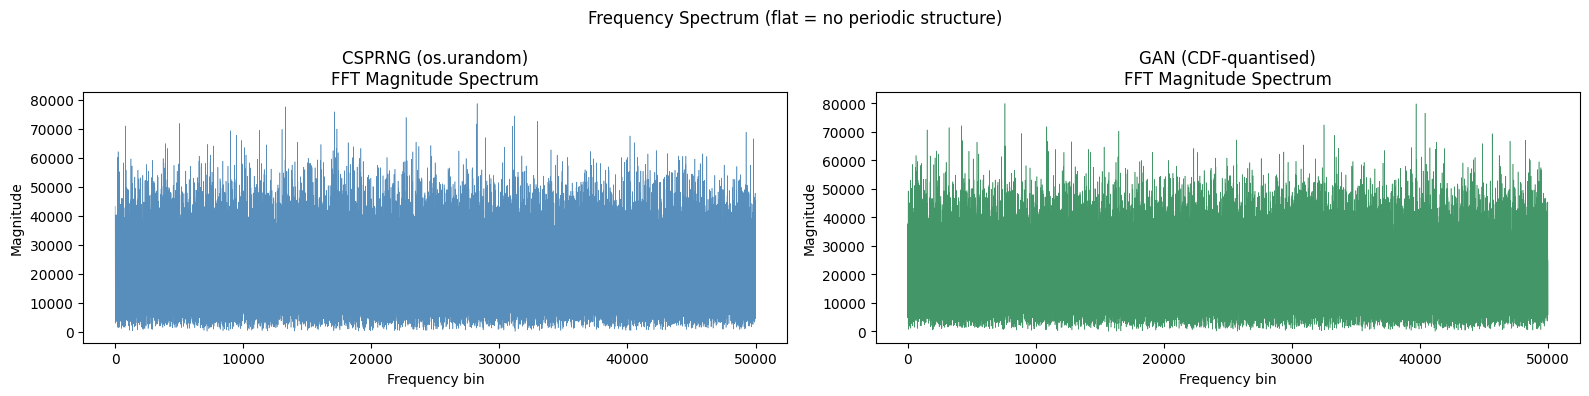

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for ax, data, label, color in zip(
    axes,
    [csprng_sample, gan_sample],
    ["CSPRNG (os.urandom)", "GAN (CDF-quantised)"],
    ["steelblue", "seagreen"],
):
    arr = np.frombuffer(data, dtype=np.uint8).astype(np.float64)
    spectrum = np.abs(fft(arr - arr.mean()))
    half = len(spectrum) // 2
    ax.plot(spectrum[1:half], linewidth=0.4, alpha=0.9, color=color)
    ax.set_title(f"{label}\nFFT Magnitude Spectrum")
    ax.set_xlabel("Frequency bin")
    ax.set_ylabel("Magnitude")

plt.suptitle("Frequency Spectrum (flat = no periodic structure)", fontsize=12)
plt.tight_layout()
plt.savefig("fft_spectrum.png", dpi=120)
plt.show()


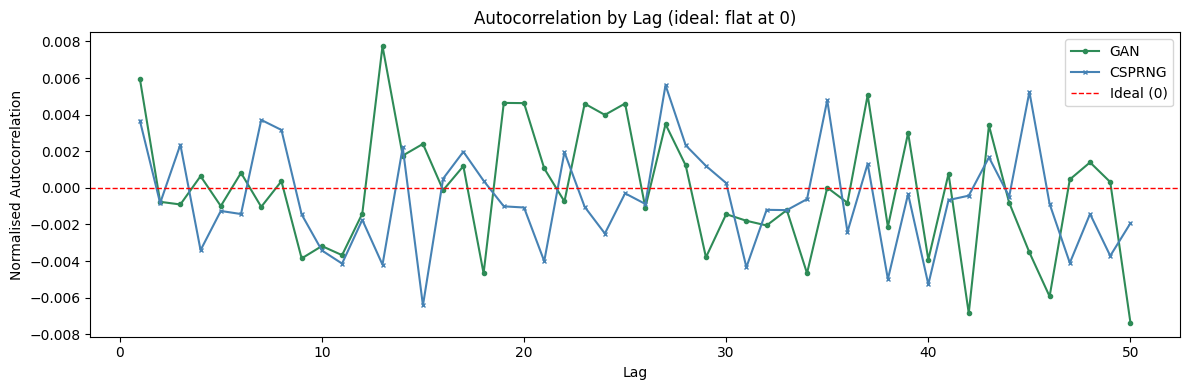

GAN    max |autocorr| across lags 1-50: 0.0077
CSPRNG max |autocorr| across lags 1-50: 0.0064


In [47]:
lags = list(range(1, 51))
gan_autocorrs    = [autocorrelation(gan_sample,    lag=l) for l in lags]
csprng_autocorrs = [autocorrelation(csprng_sample, lag=l) for l in lags]

plt.figure(figsize=(12, 4))
plt.plot(lags, gan_autocorrs,    marker="o", markersize=3, label="GAN",    color="seagreen")
plt.plot(lags, csprng_autocorrs, marker="x", markersize=3, label="CSPRNG", color="steelblue")
plt.axhline(0.0, color="red", linestyle="--", linewidth=1, label="Ideal (0)")
plt.title("Autocorrelation by Lag (ideal: flat at 0)")
plt.xlabel("Lag")
plt.ylabel("Normalised Autocorrelation")
plt.legend()
plt.tight_layout()
plt.savefig("autocorrelation_profile.png", dpi=120)
plt.show()

print(f"GAN    max |autocorr| across lags 1-50: {max(abs(v) for v in gan_autocorrs):.4f}")
print(f"CSPRNG max |autocorr| across lags 1-50: {max(abs(v) for v in csprng_autocorrs):.4f}")
